Total Detected Anomalies: 799
Anomalies saved to svm_detected_anomalies.csv


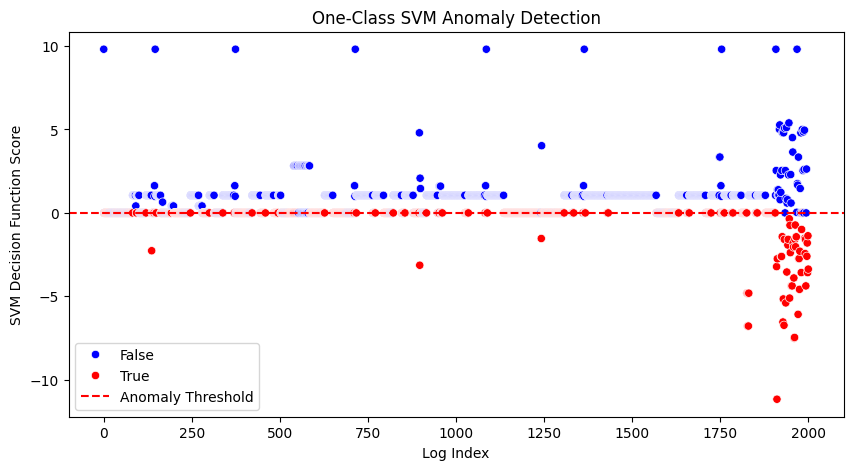

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
file_path = "Linux_2k.log_structured.csv"
df = pd.read_csv(file_path, header=None, names=["log"])

# Convert logs to numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=500)
X_tfidf = vectorizer.fit_transform(df["log"]).toarray()

# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_tfidf)

# Train One-Class SVM model
oc_svm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)  # nu is the anomaly proportion
oc_svm.fit(X_scaled)

# Predict anomalies (-1 = anomaly, 1 = normal)
df["Anomaly"] = oc_svm.predict(X_scaled)
df["Anomaly"] = df["Anomaly"].apply(lambda x: True if x == -1 else False)

# Count anomalies
num_anomalies = df["Anomaly"].sum()
print(f"Total Detected Anomalies: {num_anomalies}")

# Extract and save anomalies
anomalies = df[df["Anomaly"] == True]
anomalies.to_csv("2k_svm_detected_anomalies.csv", index=False)
print("Anomalies saved to svm_detected_anomalies.csv")

# Visualize anomalies
plt.figure(figsize=(10, 5))
sns.scatterplot(x=range(len(df)), y=oc_svm.decision_function(X_scaled), hue=df["Anomaly"], palette={True: "red", False: "blue"})
plt.axhline(0, color='r', linestyle='dashed', label="Anomaly Threshold")
plt.xlabel("Log Index")
plt.ylabel("SVM Decision Function Score")
plt.title("One-Class SVM Anomaly Detection")
plt.legend()
plt.show()
